# BinWaves example in Cantabria (Propagation)

**In this notebook**: 
<br><br>
Here is where the construction of the library of pre-run cases for all the monochromatic wave systems is made.
<br><br>
Steps:
- Generates wave conditions for all given frequencies and directions.
- Generates SWAN cases and runs them.
- Extracts SWAN cases and saves output.
- Plots the library for all the cases and some larger example ones.

## Generate computational bathymetry

In [1]:
import xarray as xr
bathy = -(
    xr.open_dataset("outputs/GEBCO_Duke_100m.nc")
    .rename({"cx": "lon", "cy": "lat"})
    .transpose("lat", "lon")
    .isel(lon=slice(0, None, 5), lat=slice(0, None, 5))  # This gives 500m resolution
    .sortby("lat", ascending=False)
    .elevation
    # .sortby("lat")
)
bathy

<xarray.DataArray 'elevation' (lat: 443, lon: 364)> Size: 1MB
array([[            nan, -6.80194969e+00, -6.56631083e+00, ...,
         1.83257012e+03,  1.84502895e+03,  1.85890320e+03],
       [            nan, -1.13743113e+01, -8.72984567e+00, ...,
         1.80585402e+03,  1.81989065e+03,  1.83333799e+03],
       [            nan, -1.27134870e+01, -1.04539205e+01, ...,
         1.77458375e+03,  1.79193151e+03,  1.80628927e+03],
       ...,
       [            nan,  1.00000000e+00,  1.00000000e+00, ...,
         3.22368471e+03,  3.22471126e+03,  3.22010700e+03],
       [            nan,  1.00000000e+00,  1.00000000e+00, ...,
         3.22843965e+03,  3.22775623e+03,  3.22197481e+03],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan]],
      shape=(443, 364))
Coordinates:
  * lon      (lon) float64 3kB 3.719e+05 3.724e+05 ... 5.529e+05 5.534e+05
  * lat      (lat) float64 4kB 4.073e+06 4.072e+06 ... 3.852e+06 3.852e+06
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

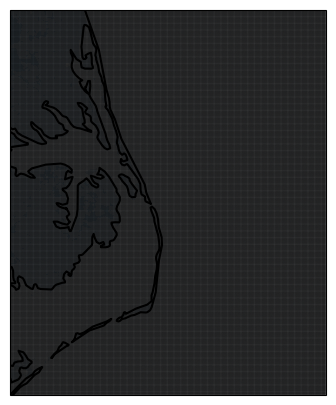

In [2]:
from utils.plotting import plot_selected_bathy

plot_selected_bathy(bathy=bathy)

In [3]:
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

fixed_parameters = generate_grid_parameters(bathy_data=bathy)
fixed_parameters

{'xpc': 371933,
 'ypc': 3851757,
 'alpc': 0,
 'xlenc': 181500,
 'ylenc': 221000,
 'mxc': 363,
 'myc': 442,
 'xpinp': np.float64(371933.1394073728),
 'ypinp': np.float64(3851757.252582026),
 'alpinp': 0,
 'mxinp': 363,
 'myinp': 442,
 'dxinp': np.float64(500.0),
 'dyinp': np.float64(500.0)}

## Create SWAN cases

In [5]:
from bluemath_tk.waves.binwaves import generate_swan_cases
from utils.wrapper import example_directions, example_frequencies

# Generate swan model parameters
example_directions = example_directions
swan_cases_df = (
    generate_swan_cases(
        directions_array=example_directions,
        frequencies_array=example_frequencies,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df

,dir,freq,hs,tp,spr,gamma
0,7.5,0.035000,1.0,28.5714,2.0,50.0
1,7.5,0.038500,1.0,25.9740,2.0,50.0
2,7.5,0.042350,1.0,23.6128,2.0,50.0
3,7.5,0.046585,1.0,21.4661,2.0,50.0
4,7.5,0.051243,1.0,19.5147,2.0,50.0
...,...,...,...,...,...,...
691,352.5,0.344741,0.1,2.9007,2.0,50.0
692,352.5,0.379215,0.1,2.6370,2.0,50.0
693,352.5,0.417136,0.1,2.3973,2.0,50.0
694,352.5,0.458850,0.1,2.1794,2.0,50.0


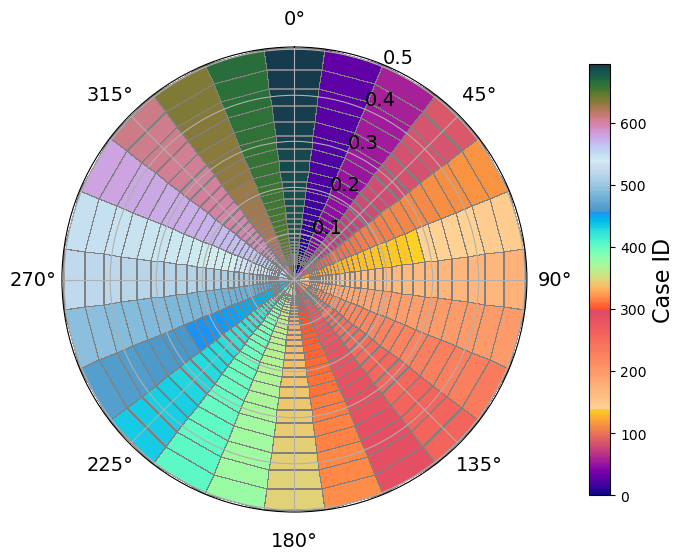

In [6]:
import numpy as np
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid

plot_selected_cases_grid(
    frequencies=np.array(example_frequencies),
    directions=np.array(example_directions),
    figsize=(8, 8),
)

## Build and run SWAN cases

In [7]:
import os
from utils.wrapper import BinWavesWrapper

# Define the input templates and output directory for the wrapper

templates_dir = os.path.join(os.getcwd(), "templates")
templates_name = ["INPUT"]
output_dir = os.path.join(os.getcwd(), "Duck_cases")

# Create an instance of the SWAN model wrapper

swan_wrapper = BinWavesWrapper(
    templates_dir=templates_dir,
    templates_name=templates_name,
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    depth_dataarray=bathy,
)

2025-05-19 18:52:20,580 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2025-05-19 18:52:20,580 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2025-05-19 18:52:20,581 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2025-05-19 18:52:20,581 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2025-05-19 18:52:20,581 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2025-05-19 18:52:20,582 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [8]:
swan_wrapper.locations

array([[ 514397.61, 4051843.74]])

In [9]:
# Build the input files

swan_wrapper.build_cases(mode="one_by_one")
swan_cases_df.to_csv(os.path.join(output_dir, "swan_cases.csv"), index=False)

# Set the cases directories from the output directory
# Execute if the cases are already built

# swan_wrapper.set_cases_dirs_from_output_dir()

KeyboardInterrupt: 

In [9]:
# Run the model

swan_wrapper.run_cases_in_background(launcher="/software/geocean/swan/swan_serial.exe", num_workers=20)

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Show all rows
swan_wrapper.monitor_cases()

In [ ]:
# # Monitor running cases

# swan_wrapper.monitor_cases()

In [ ]:
# Post-process the output files

cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

In [ ]:
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=5),
)

## Plot ALL pre-run cases

In [ ]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,
    ),
    cases_to_plot=[0, 300, 600],
    num_directions=len(example_directions),
    num_frequencies=len(example_frequencies),
)

## Extract kp coefficients

In [13]:
# ps aux | grep python
# pkill -f "python"

In [ ]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)
kp_coefficients

In [ ]:
# kp_coefficients.to_dataset(name="kps").drop(["time", "lat", "lon"]).assign_coords(
#     utm_x=(("site"), swan_wrapper.locations[:, 0]),
#     utm_y=(("site"), swan_wrapper.locations[:, 1]),
# ).to_netcdf("outputs/kp_coefficients.nc")
# If you only need to drop 'time':
kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
    utm_x=(("site"), swan_wrapper.locations[:, 0]),
    utm_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs/kp_coefficients.nc")

In [ ]:
import numpy as np
import json
from pyproj import Transformer

def mesh_to_geojson(locations_x, locations_y, output_file):
    """
    Convert mesh coordinates to GeoJSON format.
    
    Args:
        locations_x: 2D array of longitude coordinates (WGS84)
        locations_y: 2D array of latitude coordinates (WGS84)
        output_file: Path to output GeoJSON file
    """
    features = []
    
    # Flatten the mesh and create features
    for i, (lon, lat) in enumerate(zip(locations_x.flatten(), locations_y.flatten())):
        feature = {
            "type": "Feature",
            "properties": {
                "id": f"{i:04d}",  # Format ID as 4-digit string
                "type": "BinWaves"
            },
            "geometry": {
                "type": "Point",
                "coordinates": [float(lon), float(lat)]
            }
        }
        features.append(feature)
    
    # Create the GeoJSON structure
    geojson = {
        "type": "FeatureCollection",
        "features": features
    }
    
    # Write to file
    with open(output_file, 'w') as f:
        json.dump(geojson, f, indent=2)

if __name__ == "__main__":
    # Create transformers for coordinate conversion
    wgs84_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)
    utm_to_wgs84 = Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True)
    
    # Define WGS84 coordinate ranges (longitude, latitude in degrees)
    lon_min, lon_max = -76.4, -74.4  # longitude range
    lat_min, lat_max = 34.8, 36.8   # latitude range
    
    # Convert WGS84 ranges to UTM for mesh creation
    utm_x_min, utm_y_min = wgs84_to_utm.transform(lon_min, lat_min)
    utm_x_max, utm_y_max = wgs84_to_utm.transform(lon_max, lat_max)
    
    # Calculate number of points for desired spacing
    spacing = 500  # meters
    step = 10      # take every Nth point
    
    # Calculate total number of points needed for the spacing
    n_x_total = int((utm_x_max - utm_x_min) / spacing) + 1
    n_y_total = int((utm_y_max - utm_y_min) / spacing) + 1
    
    # Calculate number of points after applying step
    n_x = n_x_total // step
    n_y = n_y_total // step
    
    # Create mesh in UTM coordinates with step
    utm_x = np.linspace(utm_x_min, utm_x_max, n_x_total)[::step]
    utm_y = np.linspace(utm_y_min, utm_y_max, n_y_total)[::step]
    utm_x_mesh, utm_y_mesh = np.meshgrid(utm_x, utm_y)
    
    # Convert UTM mesh back to WGS84
    lon_mesh = np.zeros_like(utm_x_mesh)
    lat_mesh = np.zeros_like(utm_y_mesh)
    
    for i in range(utm_x_mesh.shape[0]):
        for j in range(utm_x_mesh.shape[1]):
            lon_mesh[i,j], lat_mesh[i,j] = utm_to_wgs84.transform(utm_x_mesh[i,j], utm_y_mesh[i,j])
    
    # Convert to GeoJSON
    output_file = "mesh_points.geojson"
    mesh_to_geojson(lon_mesh, lat_mesh, output_file)
    print(f"Created GeoJSON file: {output_file}")
    print(f"Created mesh with {n_x}x{n_y} points (total: {n_x*n_y} points)")
    print(f"Original spacing: {spacing}m")
    print(f"Taking every {step}th point")
    print(f"Effective spacing: {spacing * step}m")
    print(f"WGS84 range: Lon({lon_min}, {lon_max}), Lat({lat_min}, {lat_max})")
    print(f"UTM range: X({utm_x_min:.2f}, {utm_x_max:.2f}), Y({utm_y_min:.2f}, {utm_y_max:.2f})")

In [ ]:
import numpy as np
import json
from pyproj import Transformer

def mesh_to_geojson(locations_x, locations_y, output_file):
    """
    Convert mesh coordinates to GeoJSON format.
    
    Args:
        locations_x: 2D array of longitude coordinates (WGS84)
        locations_y: 2D array of latitude coordinates (WGS84)
        output_file: Path to output GeoJSON file
    """
    features = []
    
    # Flatten the mesh and create features
    for i, (lon, lat) in enumerate(zip(locations_x.flatten(), locations_y.flatten())):
        feature = {
            "type": "Feature",
            "properties": {
                "id": f"{i:04d}",  # Format ID as 4-digit string
                "type": "BinWaves"
            },
            "geometry": {
                "type": "Point",
                "coordinates": [float(lon), float(lat)]
            }
        }
        features.append(feature)
    
    # Create the GeoJSON structure
    geojson = {
        "type": "FeatureCollection",
        "features": features
    }
    
    # Write to file
    with open(output_file, 'w') as f:
        json.dump(geojson, f, indent=2)

if __name__ == "__main__":
    # Create transformers for coordinate conversion
    wgs84_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)
    utm_to_wgs84 = Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True)
    
    # Your WGS84 coordinates
    lon_min, lon_max = -76.4, -74.4  # longitude range
    lat_min, lat_max = 34.8, 36.8    # latitude range
    
    # Convert WGS84 to UTM
    utm_x_min, utm_y_min = wgs84_to_utm.transform(lon_min, lat_min)
    utm_x_max, utm_y_max = wgs84_to_utm.transform(lon_max, lat_max)
    
    # Round to nearest meter
    utm_x_min = int(utm_x_min)
    utm_x_max = int(utm_x_max)
    utm_y_min = int(utm_y_min)
    utm_y_max = int(utm_y_max)
    
    # Create arrays with step=10 like in the wrapper
    utm_x = np.arange(utm_x_min, utm_x_max + 1, 10)
    utm_y = np.arange(utm_y_min, utm_y_max + 1, 10)
    
    # Create the mesh in UTM coordinates
    utm_x_mesh, utm_y_mesh = np.meshgrid(utm_x, utm_y)
    
    # Convert UTM mesh back to WGS84
    lon_mesh = np.zeros_like(utm_x_mesh)
    lat_mesh = np.zeros_like(utm_y_mesh)
    
    for i in range(utm_x_mesh.shape[0]):
        for j in range(utm_x_mesh.shape[1]):
            lon_mesh[i,j], lat_mesh[i,j] = utm_to_wgs84.transform(utm_x_mesh[i,j], utm_y_mesh[i,j])
    
    # Convert to GeoJSON
    output_file = "mesh_points.geojson"
    mesh_to_geojson(lon_mesh, lat_mesh, output_file)
    print(f"Created GeoJSON file: {output_file}")
    print(f"Created mesh with {len(utm_x)}x{len(utm_y)} points (total: {len(utm_x)*len(utm_y)} points)")
    print(f"WGS84 input range: Lon({lon_min}, {lon_max}), Lat({lat_min}, {lat_max})")
    print(f"UTM range: X({utm_x_min}, {utm_x_max}), Y({utm_y_min}, {utm_y_max})")
    print(f"WGS84 output range: Lon({lon_mesh.min():.6f}, {lon_mesh.max():.6f}), Lat({lat_mesh.min():.6f}, {lat_mesh.max():.6f})")
    print(f"Step size: 10 meters")